# FAA Wildlife Strike Analysis 
### Draft Visual Review - Chart Generation

***Which aircraft components are hit hardest during takeoff and landing, and how does that risk shift by season and by state?***

Data Visualization: Team Capstone WORKING DRAFT for cross-team review.    
Data: FAA Wildlife Strike Database, wildlife.faa.gov (356,086 reported strikes) - `data/FAA Strike Analysis Working.xlsx`  
Prepared by: DIS-Group 1  

**Research question:** During takeoff and landing, which aircraft components
are most frequently damaged in wildlife strikes, and how does the frequency
and severity of that damage shift with the season and the state where the
strike occurs?

**Scope:** The analysis focuses on four critical flight phases: 
1. Take-off Run 
1. Climb 
1. Approach 
1. Landing Roll 

Analysis is restricted to the four flight phases where a strike is
most consequential: *Take-off Run* and *Climb* (grouped as "takeoff-related"),
and *Approach* and *Landing Roll* (grouped as "landing-related"). A report
counts as "severe" when the FAA classified the resulting damage as
*Substantial* or *Destroyed*.

**Output:** Each section below computes its own aggregate from the raw sheets
and renders one chart, saved to `figures/`. Colors and typography follow a
single palette so all five read as one system (see the style-constants cell).

Takeoff-related = Take-off Run + Climb 

Landing-related = Approach + Landing Roll 

Severe damage = FAA damage levels Substantial (S) or Destroyed (D). 

We focus on the four flight phases where a wildlife strike is most consequential: 
Take-off Run and Climb (grouped as “takeoff-related”), and Approach and Landing Roll 
(grouped as “landing-related”). We call a report “severe” when the FAA classified 
the resulting damage as Substantial or Destroyed. Visual 1 below shows why we drew 
the line there instead of covering the full flight profile. 

Run all cells top to bottom. The first data-load cell is the slow step
(~1 minute, mostly the 356k-row `Strike Analysis` sheet) — its result is
cached to `data/cache/*.pkl` so later runs are fast until the source
workbook changes.


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
import geopandas as gpd

pd.set_option("display.max_columns", 30)


## Style constants

One shared palette across all five charts: blue/orange as the two-series
categorical pair (takeoff-related vs. landing-related), a blue sequential
ramp for the choropleth, and a consistent ink/grid/type system. Values match
the validated palette used for the rest of the report.


In [29]:
# -- Categorical (2-series: takeoff-related vs. landing-related) --
BLUE = "#2A78D6"
ORANGE = "#EB6834"

# -- Sequential blue ramp, for the choropleth (light -> dark) --
SEQ_BLUE_STEPS = [
    "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5",
    "#256abf", "#184f95", "#0d366b",
]
SEQ_BLUE = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE_STEPS)

# -- Ink / chrome --
INK = "#0B0B0B"        # primary text
INK2 = "#52514E"       # secondary text (subtitles, captions)
MUTED = "#898781"      # axis ticks / muted labels
GRID = "#E1E0D9"       # hairline gridlines
TINT_BLUE = "#EAF2FC"  # light wash behind callouts
SURFACE = "#FCFCFB"    # chart background

FONT = "DejaVu Sans"   # matplotlib default sans; swap for your house font
plt.rcParams.update({
    "font.family": FONT,
    "text.color": INK,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK2,
    "xtick.color": MUTED,
    "ytick.color": INK,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
})

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)


def add_titles(fig, title, subtitle, top=0.86):
    """Title + subtitle without overlap: suptitle for the bold headline,
    fig.text for the lighter subtitle, subplots_adjust to reserve the space.
    """
    fig.suptitle(title, x=0.02, ha="left", fontsize=13.5, fontweight="bold", color=INK)
    fig.text(0.02, top, subtitle, ha="left", va="top", fontsize=9.5, color=INK2)
    fig.subplots_adjust(top=top - 0.06)


def clean_axes(ax, grid_axis="x"):
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)


## Load the data

Both sheets already carry the derived columns the team built (`Critical
Phase`, `Flight Group`, `Severe Damage`, `Season`, `Component`, ...) — we
only aggregate, nothing is re-derived here. One data-quality fix applied on
load: the source sheet has `Wing/Rotar` as a component name (a typo); it's
relabeled to `Wing/Rotor` for display.


In [30]:
XLSX_PATH = Path("data/FAA Strike Analysis Working.xlsx")
CACHE_DIR = Path("data/cache")
CACHE_DIR.mkdir(exist_ok=True)

CRITICAL_PHASES = ["Take-off Run", "Climb", "Approach", "Landing Roll"]
SEASON_ORDER = ["Winter", "Spring", "Summer", "Fall"]


def load_sheet(sheet_name, cache_name):
    cache_path = CACHE_DIR / cache_name
    if cache_path.exists() and cache_path.stat().st_mtime > XLSX_PATH.stat().st_mtime:
        return pd.read_pickle(cache_path)
    df = pd.read_excel(XLSX_PATH, sheet_name=sheet_name, engine="openpyxl")
    df.to_pickle(cache_path)
    return df


component = load_sheet("Component Analysis", "component_analysis.pkl")
strike = load_sheet("Strike Analysis", "strike_analysis.pkl")

component["Component"] = component["Component"].replace({"Wing/Rotar": "Wing/Rotor"})

print(f"Component Analysis: {component.shape[0]:,} rows")
print(f"Strike Analysis:     {strike.shape[0]:,} rows")


Component Analysis: 26,590 rows
Strike Analysis:     356,086 rows


## Visual 1 — Why we scoped to these four phases

*Purpose:* identify which critical flight phase has the highest damage rate,
to justify why the rest of the analysis stays inside these four phases.


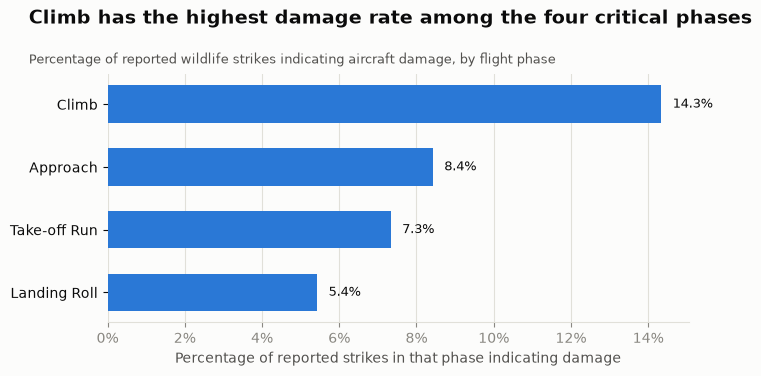

Critical Phase
Climb           14.3
Approach         8.4
Take-off Run     7.3
Landing Roll     5.4
Name: INDICATED_DAMAGE, dtype: float64


In [31]:
crit = strike[strike["Critical Phase"].isin(CRITICAL_PHASES)]
phase_rate = (
    crit.groupby("Critical Phase")["INDICATED_DAMAGE"]
    .mean()
    .reindex(CRITICAL_PHASES)
    .sort_values(ascending=True)  # ascending so the top bar (highest) plots last -> top
)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
bars = ax.barh(phase_rate.index, phase_rate.values * 100, color=BLUE, zorder=3, height=0.6)
for bar, val in zip(bars, phase_rate.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val * 100:.1f}%", va="center", fontsize=9.5, color=INK)

ax.set_xlabel("Percentage of reported strikes in that phase indicating damage")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
clean_axes(ax)

top_phase = phase_rate.idxmax()
add_titles(
    fig,
    f"{top_phase} has the highest damage rate among the four critical phases",
    "Percentage of reported wildlife strikes indicating aircraft damage, by flight phase",
)
fig.savefig(FIG_DIR / "chart_phase.png", dpi=300, bbox_inches="tight")
plt.show()

print(phase_rate.sort_values(ascending=False).mul(100).round(1))


## Visual 2 — Which components get hit

**Purpose:** identify which aircraft components are most frequently damaged,
and whether that differs between takeoff and landing.


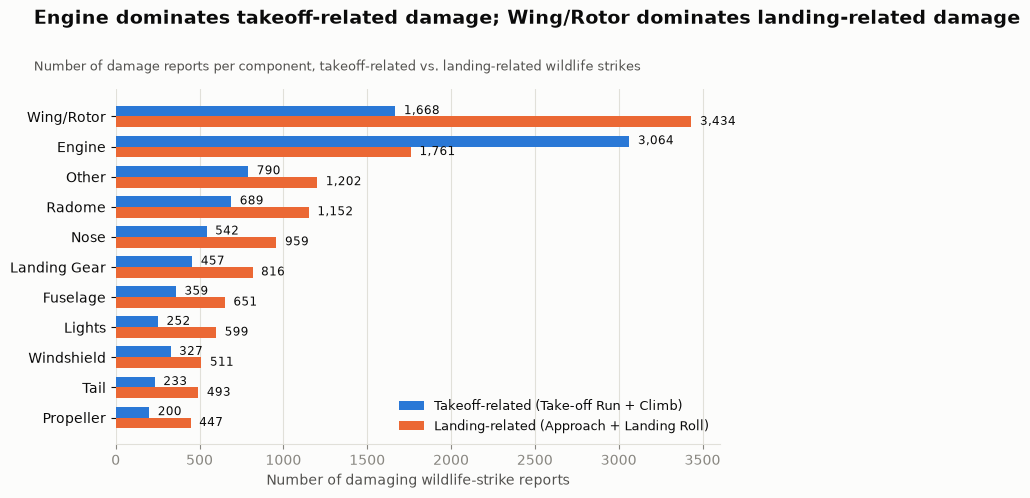

Flight Group,Takeoff Related,Landing Related,Total
Component,,,
Propeller,200,447,647
Tail,233,493,726
Windshield,327,511,838
Lights,252,599,851
Fuselage,359,651,1010
Landing Gear,457,816,1273
Nose,542,959,1501
Radome,689,1152,1841
Other,790,1202,1992


In [32]:
# The sheet also carries some non-critical-phase ("Other" Flight Group)
# rows; keep only takeoff- and landing-related so this matches the report's
# stated scope.
comp_freq = (
    component.groupby(["Component", "Flight Group"]).size().unstack(fill_value=0)
)
comp_freq = comp_freq[["Takeoff Related", "Landing Related"]]
comp_freq["Total"] = comp_freq["Takeoff Related"] + comp_freq["Landing Related"]
comp_freq = comp_freq.sort_values("Total", ascending=True)  # ascending -> largest at top of barh

fig, ax = plt.subplots(figsize=(7.8, 5))
y = np.arange(len(comp_freq))
h = 0.36
b1 = ax.barh(y + h / 2, comp_freq["Takeoff Related"], height=h, color=BLUE,
             label="Takeoff-related (Take-off Run + Climb)", zorder=3)
b2 = ax.barh(y - h / 2, comp_freq["Landing Related"], height=h, color=ORANGE,
             label="Landing-related (Approach + Landing Roll)", zorder=3)
for bars in (b1, b2):
    for bar in bars:
        w = bar.get_width()
        ax.text(w + max(comp_freq['Total']) * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{int(w):,}", va="center", fontsize=8.5, color=INK)

ax.set_yticks(y)
ax.set_yticklabels(comp_freq.index)
ax.set_xlabel("Number of damaging wildlife-strike reports")
ax.legend(loc="lower right", frameon=False, fontsize=9)
clean_axes(ax)

top_takeoff = comp_freq["Takeoff Related"].idxmax()
top_landing = comp_freq["Landing Related"].idxmax()
add_titles(
    fig,
    f"{top_takeoff} dominates takeoff-related damage; {top_landing} dominates landing-related damage",
    "Number of damage reports per component, takeoff-related vs. landing-related wildlife strikes",
    top=0.88,
)
fig.savefig(FIG_DIR / "chart_components.png", dpi=300, bbox_inches="tight")
plt.show()

comp_freq


**Key finding:** Engines are the single most frequently damaged component overall, and they dominate takeoff-related damage specifically (3,064 reports vs. 1,761 on landing). Wing/Rotor damage is the more common story on landing (3,434 reports), it's the top landing-related component even though it ranks second overall.

**Rule:** Takeoff-related strikes include Take-off Run and Climb, while landing-related strikes include Approach and Landing Roll. Each component percentage represents the share of damaging wildlife-strike reports in that flight group that involved damage to that component. 

## Visual 3 — Which of those hits are worst

**Purpose:** Identify which components, when they are damaged, are most
likely to see severe (Substantial or Destroyed) damage.


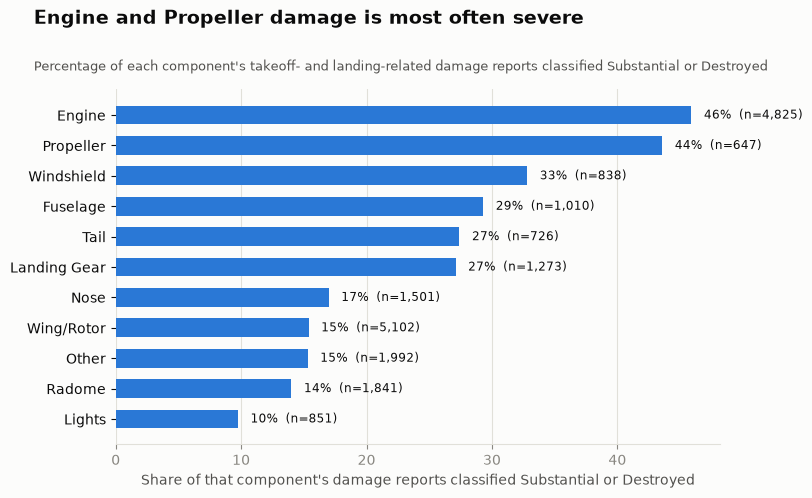

,mean,count
Component,,
Engine,0.459067,4825
Propeller,0.435858,647
Windshield,0.328162,838
Fuselage,0.293069,1010
Tail,0.274105,726
Landing Gear,0.271013,1273
Nose,0.169887,1501
Wing/Rotor,0.153861,5102
Other,0.153112,1992


In [33]:
# Same takeoff/landing scope as everywhere else in this notebook -- the
# Component Analysis sheet also carries some non-critical-phase ("Other"
# Flight Group) rows, which must be excluded here too or the rates drift
# from the rest of the report.
comp_critical = component[component["Flight Group"].isin(["Takeoff Related", "Landing Related"])]

comp_sev = (
    comp_critical.groupby("Component")["Severe Damage"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=True)
)

fig, ax = plt.subplots(figsize=(7.8, 5))
bars = ax.barh(comp_sev.index, comp_sev["mean"] * 100, color=BLUE, zorder=3, height=0.62)
for bar, (mean, n) in zip(bars, comp_sev[["mean", "count"]].values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{mean * 100:.0f}%  (n={int(n):,})", va="center", fontsize=8.5, color=INK)

ax.set_xlabel("Share of that component's damage reports classified Substantial or Destroyed")
clean_axes(ax)

top2 = comp_sev.sort_values("mean", ascending=False).index[:2]
add_titles(
    fig,
    f"{top2[0]} and {top2[1]} damage is most often severe",
    "Percentage of each component's takeoff- and landing-related damage reports classified Substantial or Destroyed",
    top=0.88,
)
fig.savefig(FIG_DIR / "chart_severity.png", dpi=300, bbox_inches="tight")
plt.show()

comp_sev.sort_values("mean", ascending=False)


**Key finding:** Engine and propeller strikes are far more likely to be severe than any other component: 46% of engine-damage reports and 44% of propeller-damage reports are classified Substantial or Destroyed, roughly triple the rate for Wing/Rotor (15%) despite Wing/Rotor being damaged more often overall. Frequency and severity rank components differently, which is exactly why this analysis needed both views, not just one.

**Caveat:** Severity describes the overall strike event, not necessarily that component in isolation, a report where an engine was one of several components damaged is still counted as an engine-damage report.

## Visual 4 — How risk shifts by season

**Purpose:** Determine whether both the chance of any damage and the chance of
severe damage change with the season.

**Key finding:** Winter is the highest-risk season on both measures: takeoff-related strikes in winter indicate damage 17% of the time (vs. 7% in summer) and are severe 5% of the time (vs. 2% in summer), more than double summer's rate either way. Takeoff-related strikes are consistently riskier than landing-related strikes in every season, on both measures.


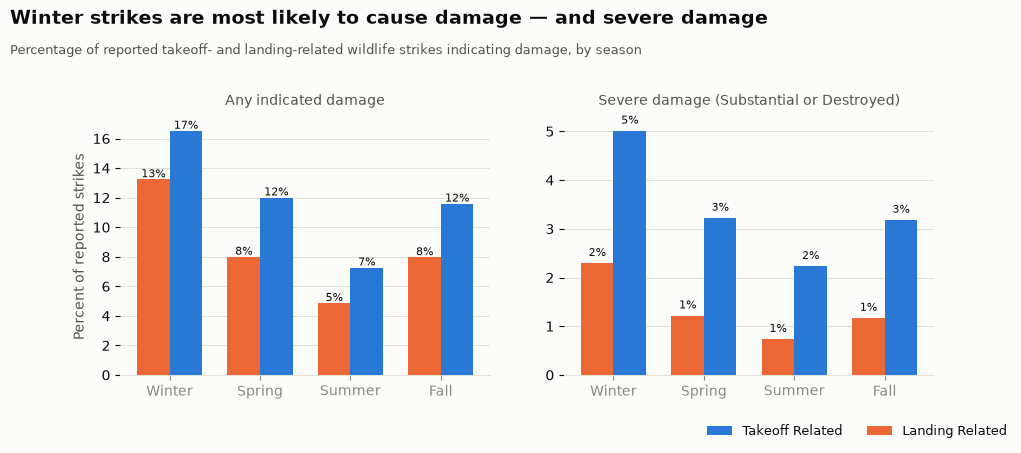

,Season,Flight Group,damage_rate,severe_rate,n
6,Winter,Landing Related,0.132299,0.022912,13530
7,Winter,Takeoff Related,0.165151,0.050086,7587
2,Spring,Landing Related,0.079862,0.012142,30966
3,Spring,Takeoff Related,0.120005,0.032198,14566
4,Summer,Landing Related,0.048559,0.007321,41661
5,Summer,Takeoff Related,0.072595,0.022291,25167
0,Fall,Landing Related,0.079502,0.011657,44351
1,Fall,Takeoff Related,0.115808,0.031776,19826


In [34]:
season = (
    crit.groupby(["Season", "Flight Group"])
    .agg(damage_rate=("INDICATED_DAMAGE", "mean"),
         severe_rate=("Severe Damage", "mean"),
         n=("INDICATED_DAMAGE", "size"))
    .reset_index()
)
season["Season"] = pd.Categorical(season["Season"], categories=SEASON_ORDER, ordered=True)
season = season.sort_values("Season")

groups = ["Takeoff Related", "Landing Related"]
colors = {"Takeoff Related": BLUE, "Landing Related": ORANGE}
x = np.arange(len(SEASON_ORDER))
w = 0.36

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))

for ax, metric, panel_title in zip(
    axes, ["damage_rate", "severe_rate"], ["Any indicated damage", "Severe damage (Substantial or Destroyed)"]
):
    for i, grp in enumerate(groups):
        vals = (
            season[season["Flight Group"] == grp]
            .set_index("Season")[metric]
            .reindex(SEASON_ORDER)
            .values
        )
        offset = w / 2 if grp == "Takeoff Related" else -w / 2
        bars = ax.bar(x + offset, vals * 100, width=w, color=colors[grp],
                       label=grp if ax is axes[0] else None, zorder=3)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
                    f"{v * 100:.0f}%", ha="center", fontsize=8, color=INK)
    ax.set_xticks(x)
    ax.set_xticklabels(SEASON_ORDER)
    ax.set_title(panel_title, fontsize=10, color=INK2, pad=10)
    clean_axes(ax, grid_axis="y")

axes[0].set_ylabel("Percent of reported strikes")
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper right",
           bbox_to_anchor=(0.98, 0.02), ncol=2, frameon=False, fontsize=9)

winter_takeoff = season[(season.Season == "Winter") & (season["Flight Group"] == "Takeoff Related")]
add_titles(
    fig,
    "Winter strikes are most likely to cause damage — and severe damage",
    "Percentage of reported takeoff- and landing-related wildlife strikes indicating damage, by season",
    top=0.90,
)
fig.subplots_adjust(top=0.72)  # extra clearance below the subtitle for the two panel titles
fig.savefig(FIG_DIR / "chart_season.png", dpi=300, bbox_inches="tight")
plt.show()

season


**Key finding:** Winter is the highest-risk season on both measures: takeoff-related strikes in winter indicate damage 17% of the time (vs. 7% in summer) and are severe 5% of the time (vs. 2% in summer), more than double summer's rate either way. Takeoff-related strikes are consistently riskier than landing-related strikes in every season, on both measures.

## Visual 5 — How risk shifts by state

**Purpose:** identify which states see the highest damage rates among reported
critical-phase strikes. States with fewer than 1,000 critical-phase reports
are excluded as unreliable.

Alaska and Hawaii are drawn as inset axes (standard US-choropleth practice)
so they don't compress the continental map or force an unnatural projection.


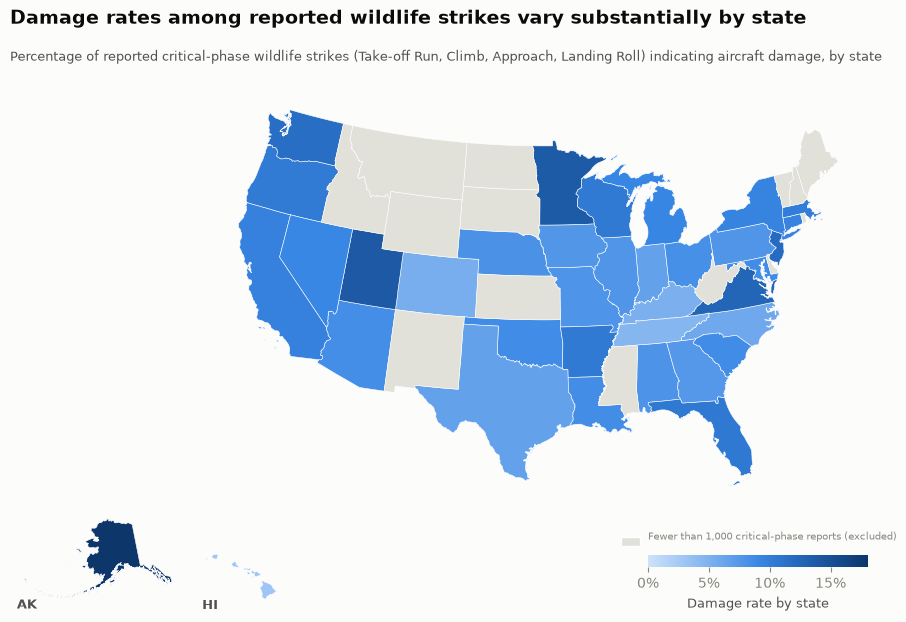

,STATE,damage_rate,severe_rate,n,name
1,AK,0.180753,0.039331,1195,Alaska
59,UT,0.138408,0.026644,2890,Utah
30,MN,0.137473,0.029122,2335,Minnesota
60,VA,0.126290,0.030541,2423,Virginia
39,NJ,0.118652,0.025146,4096,New Jersey
63,WA,0.116047,0.017906,2904,Washington
12,FL,0.104966,0.019059,17682,Florida
3,AR,0.104167,0.019231,1248,Arkansas
64,WI,0.104101,0.019829,2219,Wisconsin
48,OR,0.102481,0.021215,2781,Oregon


In [35]:
state_stats = (
    crit.groupby("STATE")
    .agg(damage_rate=("INDICATED_DAMAGE", "mean"),
         severe_rate=("Severe Damage", "mean"),
         n=("INDICATED_DAMAGE", "size"))
    .reset_index()
)
state_stats_reliable = state_stats[state_stats["n"] >= 1000].copy()

states_geo = gpd.read_file("data/us-states.geojson")

ABBR_TO_NAME = {
    'AL':'Alabama','AK':'Alaska','AZ':'Arizona','AR':'Arkansas','CA':'California',
    'CO':'Colorado','CT':'Connecticut','DE':'Delaware','DC':'District of Columbia',
    'FL':'Florida','GA':'Georgia','HI':'Hawaii','ID':'Idaho','IL':'Illinois',
    'IN':'Indiana','IA':'Iowa','KS':'Kansas','KY':'Kentucky','LA':'Louisiana',
    'ME':'Maine','MD':'Maryland','MA':'Massachusetts','MI':'Michigan','MN':'Minnesota',
    'MS':'Mississippi','MO':'Missouri','MT':'Montana','NE':'Nebraska','NV':'Nevada',
    'NH':'New Hampshire','NJ':'New Jersey','NM':'New Mexico','NY':'New York',
    'NC':'North Carolina','ND':'North Dakota','OH':'Ohio','OK':'Oklahoma','OR':'Oregon',
    'PA':'Pennsylvania','RI':'Rhode Island','SC':'South Carolina','SD':'South Dakota',
    'TN':'Tennessee','TX':'Texas','UT':'Utah','VT':'Vermont','VA':'Virginia',
    'WA':'Washington','WV':'West Virginia','WI':'Wisconsin','WY':'Wyoming',
}
state_stats_reliable["name"] = state_stats_reliable["STATE"].map(ABBR_TO_NAME)

merged = states_geo.merge(state_stats_reliable, on="name", how="left")

vmin, vmax = 0, state_stats_reliable["damage_rate"].max()

def draw_choropleth(ax, subset, crs, extent=None):
    proj = subset.to_crs(crs)
    proj.plot(
        ax=ax, column="damage_rate", cmap=SEQ_BLUE, vmin=vmin, vmax=vmax,
        missing_kwds={"color": "#e1e0d9", "edgecolor": "white", "linewidth": 0.4},
        edgecolor="white", linewidth=0.4,
    )
    ax.set_axis_off()
    # Equal-aspect geographic data rarely fills a rectangular axes box, and
    # since the axes background patch is opaque (SURFACE color), it would
    # otherwise leave dead space in the saved figure even with a tight
    # bbox. Make the patch transparent so savefig(bbox_inches="tight")
    # crops to the actual drawn shapes instead of the full box.
    ax.set_facecolor("none")
    if extent:
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])

# Layout: dedicated, NON-overlapping bands -- main map on top, a bottom
# strip holding the AK/HI insets and the colorbar. (An earlier version let
# the AK/HI inset boxes overlap the main map's own axes region, which hid
# the real West Coast states behind them -- keeping every axes in its own
# horizontal band avoids that regardless of how the projected CONUS shape
# happens to fill its box.)
fig = plt.figure(figsize=(11, 6.2))
ax_main = fig.add_axes([0.02, 0.17, 0.96, 0.67])
# The source geojson also carries Puerto Rico, Guam, American Samoa, the
# Northern Mariana Islands, and the US Virgin Islands. None have strike
# data (they'd render gray via missing_kwds), but left in they wreck the
# CONUS Albers projection's bounding box -- it stretches across the whole
# Pacific/Caribbean, shrinking the actual 48-state map to a speck. Keep
# this subset to the 48 states + DC only.
NON_CONUS = ["Alaska", "Hawaii", "Puerto Rico", "Guam", "American Samoa",
             "Commonwealth of the Northern Mariana Islands", "United States Virgin Islands"]
conus = merged[~merged["name"].isin(NON_CONUS)]
draw_choropleth(ax_main, conus, "EPSG:5070")

ax_ak = fig.add_axes([0.02, 0.015, 0.16, 0.14])
ak = merged[merged["name"] == "Alaska"]
draw_choropleth(ax_ak, ak, "EPSG:3338")
ax_ak.text(0.0, -0.08, "AK", transform=ax_ak.transAxes, fontsize=9, fontweight="bold", color=INK2)

ax_hi = fig.add_axes([0.185, 0.015, 0.09, 0.08])
hi = merged[merged["name"] == "Hawaii"]
draw_choropleth(ax_hi, hi, "EPSG:32604")
ax_hi.text(0.0, -0.15, "HI", transform=ax_hi.transAxes, fontsize=9, fontweight="bold", color=INK2)

# Colorbar / legend, same bottom strip, clear of the insets
cax = fig.add_axes([0.60, 0.07, 0.20, 0.02])
sm = plt.cm.ScalarMappable(cmap=SEQ_BLUE, norm=plt.Normalize(vmin=vmin, vmax=vmax))
cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
cb.set_label("Damage rate by state", fontsize=9, color=INK2)
cb.ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
cb.outline.set_visible(False)

fig.text(0.60, 0.115, "Fewer than 1,000 critical-phase reports (excluded)", fontsize=7.5, color=MUTED)
fig.add_artist(plt.Rectangle((0.575, 0.105), 0.018, 0.014, transform=fig.transFigure,
                              facecolor="#e1e0d9", edgecolor="white"))

top_state = state_stats_reliable.sort_values("damage_rate", ascending=False).iloc[0]
fig.suptitle("Damage rates among reported wildlife strikes vary substantially by state",
             x=0.02, ha="left", fontsize=13.5, fontweight="bold", color=INK, y=0.97)
fig.text(0.02, 0.905, "Percentage of reported critical-phase wildlife strikes (Take-off Run, Climb, "
                      "Approach, Landing Roll) indicating aircraft damage, by state",
         ha="left", va="top", fontsize=9.5, color=INK2)

fig.savefig(FIG_DIR / "chart_map.png", dpi=300, bbox_inches="tight")
plt.show()

state_stats_reliable.sort_values("damage_rate", ascending=False).head(10)


**Key finding:** Damage rates range from about 3% (Hawaii) to 18% (Alaska) among states with at least 1,000 critical-phase reports, a six-fold spread. The pattern isn't simply about how many strikes a state reports: Alaska, Minnesota, Virginia, and Utah top the list on both the overall damage rate and the severe-damage rate (Alaska highest on both, at 18% and 4%), while big-volume states like Texas and Florida sit in the middle of the range despite having tens of thousands of reports.

**Caveat:** States with fewer than 1,000 critical-phase reports are excluded as unstable (shown in gray); a small number of non-standard location codes in the source data were also excluded. Rates reflect reported strikes, not flight volume, so they mix true geographic risk with differences in aviation activity, wildlife exposure, aircraft mix, and how consistently strikes get reported in each state.

# Limitations 

- All rates are based on reported wildlife strikes, not total aircraft operations. We can compare reported outcomes across phases, seasons, components, and states, but we cannot state the probability of damage on any individual flight. 

- Severity (Substantial or Destroyed) describes the overall strike event. When multiple components are damaged in one strike, severity is attributed to all of them. 

- State comparisons do not control differences in aviation activity; wildlife exposure, aircraft mix, or reporting practices at a higher rate is not proof of higher underlying risk. 

- Reporting is voluntary in parts of the dataset's history, so trends across states and over time may partly reflect reporting behavior rather than strike behavior. 